In [109]:
EMBEDDINGS_DIRECTORY = './vstore' # directory of stored embeddings

In [110]:

from langchain.vectorstores import FAISS
from langchain.embeddings import OpenAIEmbeddings, HuggingFaceEmbeddings
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from langsmith import traceable
from langchain.schema import Document

from typing import List, Annotated
from langsmith import Client
import pandas as pd

In [111]:

from dotenv import load_dotenv
load_dotenv()


client = Client()

In [112]:
embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")
vectorstore = FAISS.load_local(
    EMBEDDINGS_DIRECTORY,
    embeddings=embedding_model,
    allow_dangerous_deserialization=True,
)
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})



In [113]:
retriever.invoke("What is the milling machine used for?")[1].page_content[0:100]

'Do not operate a milling machine whilst talking.\n27. Beware of milling machine dangers when attendin'

In [114]:
llm = ChatOpenAI(model="gpt-5-mini", temperature=0)

llm.invoke("what are you ").content[0:100]


"I'm an AI language model created by OpenAI (often called ChatGPT). I can understand and generate tex"

In [115]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    documents: List[Document]  
    question: str
    answer: str

In [116]:
rag_prompt = """You are an assistant for question-answering tasks. 

Here is the context to use to answer the question:

{context} 

Think carefully about the above context. 

Now, review the user question:

{question}

Provide an answer to this questions using only the above context. 

Use 10 sentences maximum and keep the answer concise. 

Answer:"""

In [117]:
@traceable
def retrieve(state): # Retriver
    """
    Retrieve documents from vectorstore

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    #print("---RETRIEVE---")
    question = state["question"]

    documents_question = retriever.invoke(question)


    # Deduplicate by page content
    seen_pages = set()
    unique_documents = []
    for doc in documents_question :
        if doc.page_content not in seen_pages:
            unique_documents.append(doc)
            seen_pages.add(doc.page_content)

    #print(f"Retrieved {len(unique_documents)} unique documents for question: {question}")
    return {"documents": unique_documents}

@traceable
def generate(state):
    """

    Generate an AI response using the LLM, given the current state and retrieved documents.

    Args:
        state (dict): The current graph state, expected to contain 'messages' and 'documents'.

    Returns:
        dict: Updated state with the AI response appended to the 'messages' key.
    """
    #print("-----GENERATE------")

    question = state["question"]
    documents = state["documents"]
    
    context = "\n".join([doc.page_content for doc in documents])  # adjust if needed
    prompt = rag_prompt.format(context=context, question=question)
    generation = llm.invoke([HumanMessage(content=prompt)])
    return {"answer": generation.content}

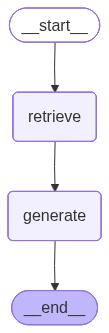

In [118]:
from langgraph.graph import START, END, StateGraph
from IPython.display import Image, display
builder = StateGraph(State)

# Nodes 
builder.add_node("retrieve", retrieve)
builder.add_node("generate", generate)

# Edges
builder.add_edge(START, "retrieve")
builder.add_edge("retrieve","generate")
builder.add_edge("generate", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [119]:
# Path to your CSV
import csv
from langsmith import Client

CSV_PATH = "evalsets/mill.csv"
DATASET_NAME = "Mill Dataset"

client = Client()

# Create or reuse dataset
try:
    dataset = client.create_dataset(dataset_name=DATASET_NAME)
except Exception:
    dataset = client.read_dataset(dataset_name=DATASET_NAME)

# 1) Load what's already there
existing = set()
for ex in client.list_examples(dataset_id=dataset.id):
    q0 = (ex.inputs or {}).get("question", "")
    a0 = (ex.outputs or {}).get("answer", "")
    existing.add((q0.strip(), a0.strip()))

# 2) Read CSV and dedupe vs existing
to_create = []
with open(CSV_PATH, newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        q = row["question"].strip()
        a = row["answer"].strip()
        if (q, a) not in existing:  # only add new
            to_create.append({"inputs": {"question": q}, "outputs": {"answer": a}})

# 3) Upload only new examples
if to_create:
    client.create_examples(dataset_id=dataset.id, examples=to_create)
print(f" Added {len(to_create)} new examples (skipped {len(existing)} existing) to '{DATASET_NAME}'.")


 Added 0 new examples (skipped 36 existing) to 'Mill Dataset'.


In [120]:
from typing_extensions import Annotated, TypedDict

# Grade output schema
class CorrectnessGrade(TypedDict):
    # Note that the order in the fields are defined is the order in which the model will generate them.
    # It is useful to put explanations before responses because it forces the model to think through
    # its final response before generating it:
    explanation: Annotated[str, ..., "Explain your reasoning for the score"]
    correct: Annotated[bool, ..., "True if the answer is correct, False otherwise."]

# Grade prompt
correctness_instructions = """You are a teacher grading a quiz. You will be given a QUESTION, the GROUND TRUTH (correct) ANSWER, and the STUDENT ANSWER. Here is the grade criteria to follow:
(1) Grade the student answers based ONLY on their factual accuracy relative to the ground truth answer. (2) Ensure that the student answer does not contain any conflicting statements.
(3) It is OK if the student answer contains more information than the ground truth answer, as long as it is factually accurate relative to the  ground truth answer.

Correctness:
A correctness value of True means that the student's answer meets all of the criteria.
A correctness value of False means that the student's answer does not meet all of the criteria.

Explain your reasoning in a step-by-step manner to ensure your reasoning and conclusion are correct. Avoid simply stating the correct answer at the outset."""

# Grader LLM
grader_llm = ChatOpenAI(model="gpt-5-mini", temperature=0).with_structured_output(
    CorrectnessGrade, method="json_schema", strict=True
)

def correctness(inputs: dict, outputs: dict, reference_outputs: dict) -> bool:
    """An evaluator for RAG answer accuracy"""
    answers = f"""\
    QUESTION: {inputs['question']}
    GROUND TRUTH ANSWER: {reference_outputs['answer']}
    STUDENT ANSWER: {outputs['answer']}"""
    # Run evaluator
    grade = grader_llm.invoke([
        {"role": "system", "content": correctness_instructions},
        {"role": "user", "content": answers}
    ])
    return grade["correct"]

In [121]:
def target(inputs: dict) -> dict:
    result = graph.invoke({"question": inputs["question"]})
    return {"answer": result["answer"]}

experiment_results = client.evaluate(
    target,
    data=DATASET_NAME,
    evaluators=[correctness],
    experiment_prefix="rag-doc-relevance",
    metadata={"version": "LCEL context, gpt-4-0125-preview"},
)

# Explore results locally as a dataframe if you have pandas installed
experiment_results.to_pandas()

View the evaluation results for experiment: 'rag-doc-relevance-8c9e1f8b' at:
https://smith.langchain.com/o/36f841e5-0d51-489b-afb0-5f60c44b4a41/datasets/cc60fdfa-7161-4bae-bb72-0697bbd742a8/compare?selectedSessions=7e3b93a6-884b-4ae0-91dc-46ae5590c6ea




36it [15:09, 25.28s/it]


,inputs.question,outputs.answer,error,reference.answer,feedback.correctness,execution_time,example_id,id
0,Speed Change handwheel,The Speed Change Handwheel (P) on the front of...,None,,False,15.975023,01bb509a-ace9-42fa-b138-452c8df9ab8b,5e358fa9-f110-41c0-b978-3a4d4d982b73
1,How to change the tool?,Stop the machine and make certain the spindle ...,None,,False,14.330106,074877a2-a177-4df9-aed1-6969bdbb80ee,fb2a6e70-5725-48ef-90f5-2121cc8a9fd4
2,Why are there 2 ranges on the speed change fl...,The speed change handwheel provides two ranges...,None,There are 2 ranges becuase this mill comes wit...,False,10.444689,088bf5ee-7f10-440f-adc6-92e3b530ac43,3b002835-de18-462d-8039-28b6ff056533
3,What kind of Clothes should I be wearing when ...,Wear close‑fitting/protective clothing and avo...,None,No Rings \nClose fitting/protective clothing m...,True,5.186599,089cb029-5e50-4e01-872b-f93e9ef11211,a5d5b9f6-1560-46a6-9892-7c9f1477b4cd
4,I have started the machine so I can change the...,1. Hold the Hi‑Neutral‑Lo lever (right rear si...,None,Do not shift hi-lo lever while motor is runnin...,True,15.051674,0ddae02d-118e-43a7-ab2f-89d09b5dabc4,ea3eb858-fda1-41a3-9836-cce29bfa7a24
5,"I am trying to change the depth through knob ""...","Use the Micrometer Nut ""F"" to set the depth: e...",None,"Knob labeled “I” is the Feed Control Lever, no...",False,13.100107,1d77bf9d-e545-4497-a32c-14c2f83f551a,8674beb8-ec07-41fc-8aab-104acdbbd9e3
6,Is gold okay to wear around this machine?,"No. Rings, watches and jewelry (including gold...",None,"No, Rings and jewellery must not be worn.",True,9.216624,1eee3c5d-0006-4ca1-935b-23c90b5e2fd6,fe3f5cc9-d4ac-41d8-812b-38db5b869898
7,What is the procedure to change the drawbar.,1. Lock the spindle by engaging the spindle br...,None,,True,9.980408,2031e5de-3654-44aa-b9a3-85a90175da60,66c30d4d-5655-40bd-b619-04b9aae760e5
8,"I already have the mill running, but I need to...",1. Hold the Hi‑Neutral‑Lo lever so the gears a...,None,Do not shift hi-lo lever while motor is runnin...,False,18.839904,2583a9c8-852f-4015-a6e7-6217bbac470b,3abdfea4-2150-40e6-9128-5305711c6ca0
9,I have the most training and safety on the flo...,"Team,\n\nDo not wear gloves when operating the...",None,Do not wear gloves while operating equipment. ...,True,18.414182,26a88f67-63e7-40b4-b965-a047b5f6f585,80d8a77a-1e00-4f7b-9ec8-67bfc50a3ba8


In [122]:
df = experiment_results.to_pandas()
# Export the dataframe to a CSV file in the data folder
df.to_csv("data/exported_data.csv", index=False)
print("Data exported to data/exported_data.csv")

Data exported to data/exported_data.csv
